In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("C:\\Users\\eulal\\OneDrive\\Escritorio\\laloseasontwo\\Minería de datos\\Data Cleaning\\netflix_titles.csv")


Validar duracion

In [2]:
df_movies = df[df['type'] == 'Movie'].copy()
df_movies = df_movies.dropna(subset=['duration'])
df_movies = df_movies[df_movies['duration'].str.contains('min', na=False)]
df_movies['duration_minutes'] = df_movies['duration'].str.extract('(\d+)').astype(float)

df_shows = df[df['type'] == 'TV Show'].copy()
df_shows = df_shows.dropna(subset=['duration'])
df_shows = df_shows[df_shows['duration'].str.contains('Season', na=False)]
df_shows['duration_seasons'] = df_shows['duration'].str.extract('(\d+)').astype(float)


<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
C:\Users\eulal\AppData\Local\Temp\ipykernel_11296\1891086178.py:4: SyntaxWarning: invalid escape sequence '\d'
  df_movies['duration_minutes'] = df_movies['duration'].str.extract('(\d+)').astype(float)
C:\Users\eulal\AppData\Local\Temp\ipykernel_11296\1891086178.py:9: SyntaxWarning: invalid escape sequence '\d'
  df_shows['duration_seasons'] = df_shows['duration'].str.extract('(\d+)').astype(float)


Columna con duracion valida

In [4]:
df_movies['duration_value'] = df_movies['duration_minutes']
df_shows['duration_value'] = df_shows['duration_seasons'] * 300


Unir datasets

In [5]:
df_cluster = pd.concat([df_movies, df_shows])
df_cluster = df_cluster.dropna(subset=['release_year', 'duration_value'])
X = df_cluster[['release_year', 'duration_value']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Metodo del codo

In [6]:
inertia = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

Grafico del codo

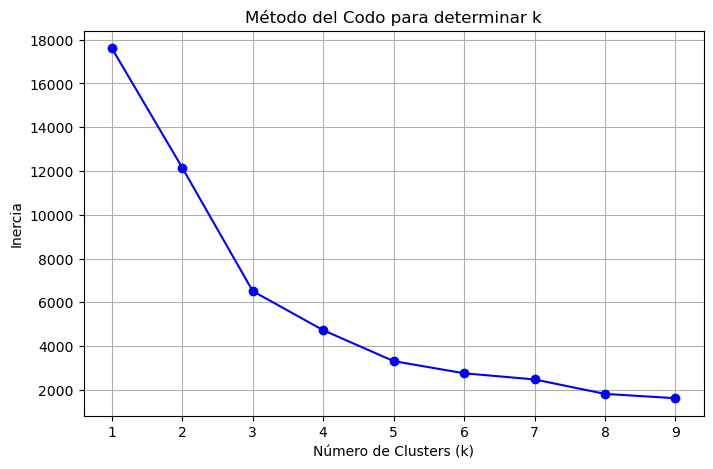

In [7]:
plt.figure(figsize=(8,5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo para determinar k')
plt.grid(True)
plt.show()

Aplicamos K-Means Optimo

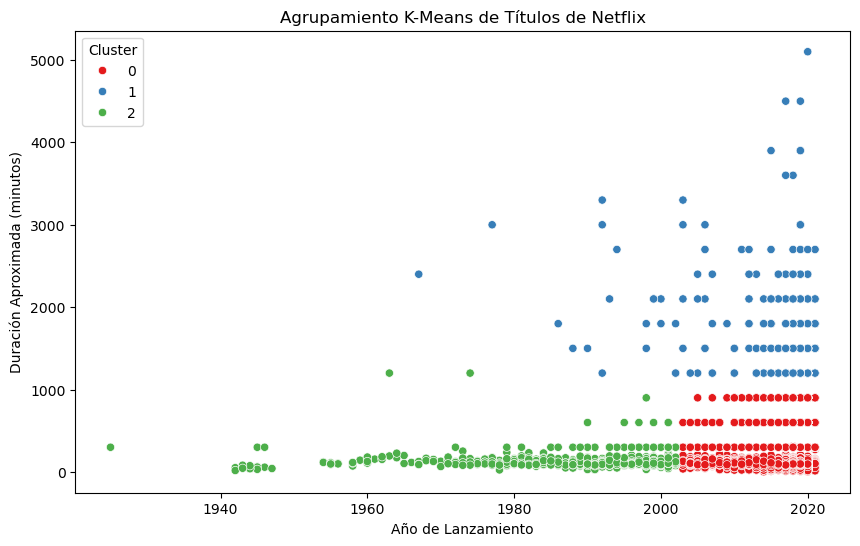

In [9]:
k_optimo = 3
kmeans = KMeans(n_clusters=k_optimo, random_state=42)
df_cluster['cluster'] = kmeans.fit_predict(X_scaled)
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df_cluster,
    x='release_year',
    y='duration_value',
    hue='cluster',
    palette='Set1'
)
plt.title('Agrupamiento K-Means de Títulos de Netflix')
plt.xlabel('Año de Lanzamiento')
plt.ylabel('Duración Aproximada (minutos)')
plt.legend(title='Cluster')
plt.show()